# TV under-reach, Social over-saturation: a simplified-DGP case study

**Objective.** `meridian_tv_underreach_case_study.ipynb` showed that a
reach-informed `ec_m` prior correctly diagnoses a large-audience TV channel
that's genuinely under-reached *and* under-frequency'd as far from
saturation, where Meridian's default `ec_m` prior (which assumes current
execution is already near half-saturation) concludes the opposite. That
notebook's data-generating process layers geo-audience heterogeneity, annual
seasonality, on/off flighting/promotional bursts, and AR(1)-autocorrelated
week-to-week noise on top of the audience/reach/frequency story -- each
independently justified as "how real campaigns actually run," but
collectively enough stochastic texture that a review of that notebook found
the headline story harder to read than it should be: `ec_m` recovery for
Display and Social was only roughly right, not tight, and the
`BudgetOptimizer` comparison in its Section 5 was accidentally neutered by
its own default spend-change bound before the underlying model comparison
ever mattered.

This notebook asks: does the same core story hold up more cleanly once that
stochastic texture is stripped down to the *minimum* needed for the model to
stay identifiable at all? (Meridian requires media to vary over time when
geo main effects are on -- a perfectly constant media series is collinear
with geo and gets flagged as unidentifiable.) TV keeps the same shape: large
target audience, low reach (~10%), low frequency (1.5/week) -- two
independent, compounding forms of under-delivery. Social keeps its shape
too: high reach (90%), high frequency (7/week) -- deliberately
over-saturated. Only the noise/texture layers on top of that flat
reach/frequency target are turned off.

**Scope note:** this notebook does not analyze `alpha_m` (adstock decay)
recovery -- that's a separate, still-open investigation, not covered here.
It focuses on `ec_m`/saturation and `roi_m`.

**How to read this notebook:**
- Section 1 builds the simplified scenario and reports the resulting true
  `ec_m`/ceiling-fraction/`roi_m`.
- Section 2 fits `default` vs `ec_alpha_only` (a `PriorDistribution` with
  both `ec_m` and `alpha_m` informed by the audience/reach/frequency/adstock
  planning inputs an advertiser would actually have) and reports the
  ceiling-fraction and `roi_m` headline diagnostics.
- Section 3 overlays the true, default-posterior, and informed-posterior
  Hill response curves.
- Section 4 compares marginal response at current execution.
- Section 5 compares budget-reallocation recommendations against the true
  DGP-optimal allocation -- both under Meridian's default `BudgetOptimizer`
  spend-change bound (`+/-30%`) and under a deliberately widened bound, since
  the default bound turned out to clip every variant to an identical
  recommendation regardless of which model was fit.

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize

from meridian.analysis import optimizer
from meridian.model import adstock_hill
from meridian.model import model

from data_simulator import SimulationConfig
from model_utils import build_model_spec
from model_utils import build_simulated_input
from model_utils import ceiling_fraction_at_median
from model_utils import filter_param_summary
from model_utils import hill_value
from model_utils import posterior_param_mean

## 1. A simplified TV under-reach / Social over-saturation scenario

Same channel story as the companion notebook -- TV: large target audience,
low reach (~10%), low frequency (1.5/week); Display: moderate; Social: high
reach (90%), high frequency (7/week), deliberately over-saturated -- but
every stochastic *texture* layer on top of that flat reach/frequency target
is turned off via `SimulationConfig` overrides:

- `geo_audience_heterogeneity_sd` -> ~0: no geo-level variation in audience
  size.
- `seasonal_amplitude` -> 0 for every channel: no annual demand cycle.
- `flight_floor` / `continuity_spike_amplitude` -> 1.0 for every channel: no
  on/off flighting dips or promotional spikes.
- `reach_noise_ar1_phi` -> 0: reach noise is plain i.i.d., not
  autocorrelated.

The only source of week-to-week variation left is small, plain i.i.d. noise
in weekly reach and frequency (`time_reach_noise_sd`, `frequency_noise_sd`)
-- the minimum needed to keep the model identifiable at all.

I0000 00:00:1785107285.491479 7058820 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


ec_m = [11.388094    1.1452765   0.31967545]


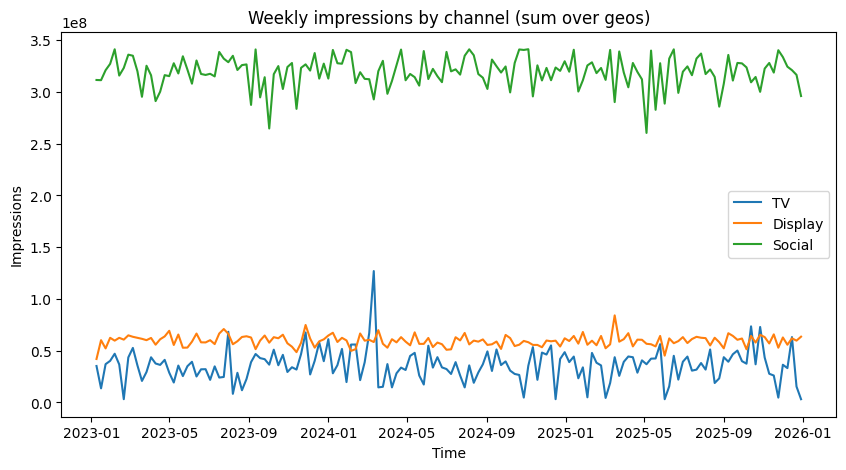

In [2]:
SIMPLE_CONFIG_OVERRIDES = {
    # Same story as `meridian_tv_underreach_case_study.ipynb`.
    'target_audience_pop_frac': {'TV': 0.60, 'Display': 0.10, 'Social': 0.15},
    'current_reach_frac': {'TV': 0.10, 'Display': 0.5, 'Social': 0.9},
    'frequency_range': {
        # Point ranges (low == high) -- flat frequency, no per-geo-time
        # spread, so "frequency" is a single clean number per channel.
        'TV': (1.5, 1.5),
        'Display': (3.5, 3.5),
        'Social': (7.0, 7.0),
    },
    'target_roi': {'TV': 8.0, 'Display': 5.0, 'Social': 3.0},

    # Flatten every noise/texture layer down to the minimum needed to keep
    # media time-varying (see Section 1 markdown above).
    'geo_audience_heterogeneity_sd': 1e-6,
    'seasonal_amplitude': {'TV': 0.0, 'Display': 0.0, 'Social': 0.0},
    'flight_floor': {'TV': 1.0, 'Display': 1.0, 'Social': 1.0},
    'continuity_spike_amplitude': {'TV': 1.0, 'Display': 1.0, 'Social': 1.0},
    'reach_noise_ar1_phi': {'TV': 0.0, 'Display': 0.0, 'Social': 0.0},
    'time_reach_noise_sd': {'TV': 0.05, 'Display': 0.05, 'Social': 0.05},
    'frequency_noise_sd': 0.05,
}

config = SimulationConfig.from_dict(SIMPLE_CONFIG_OVERRIDES)
sim, data, ground_truth = build_simulated_input(config)
sim.plot_media_time_series()
plt.show()

In [3]:
audience_national_m = sim.audience_national_m.numpy()
mean_reach_frac_m = sim.reach_count_gtm.numpy().mean(axis=(0, 1)) / (
    sim.audience_g_m.numpy().mean(axis=0)
)
mean_frequency_m = sim.frequency_gtm.numpy().mean(axis=(0, 1))
true_ec_m = sim.ec_m.numpy()
true_ceiling_frac = ceiling_fraction_at_median(true_ec_m)

for i, ch in enumerate(config.channel_names):
  print(
      f'{ch}: target audience ~ {audience_national_m[i] / 1e6:.1f}M, '
      f'reaching ~ {mean_reach_frac_m[i] * 100:.1f}% at frequency '
      f'~ {mean_frequency_m[i]:.1f}/week'
  )
print()
print(f'true ec_m (multiples of current median delivery): {true_ec_m}')
print(f'true fraction of ceiling effect captured today:   {true_ceiling_frac}')
print(f'true roi_m: {ground_truth["roi_m"]}')

TV: target audience ~ 205.1M, reaching ~ 11.6% at frequency ~ 1.5/week
Display: target audience ~ 34.2M, reaching ~ 49.8% at frequency ~ 3.5/week
Social: target audience ~ 51.3M, reaching ~ 89.0% at frequency ~ 7.0/week

true ec_m (multiples of current median delivery): [11.388094    1.1452765   0.31967545]
true fraction of ceiling effect captured today:   [0.08072267 0.46614036 0.7577621 ]
true roi_m: [8.000002  5.000003  3.0000002]


## 2. Headline diagnostic: fraction of ceiling effect captured today

Fit `default` and `ec_alpha_only` (reach-informed `ec_m` *and*
adstock-benchmark-informed `alpha_m`) on the same simplified dataset, then
compute, for the true `ec_m` and each fitted model's posterior-mean `ec_m`,
`Hill(x=1)` -- the fraction of ceiling effect achieved at exactly the
channel's own current median delivery. This is the single number that
explains the business harm: a model that believes a channel has already
captured most of its ceiling effect will show flat marginal returns and
recommend against spending more on it.

In [4]:
MAIN_VARIANTS = ['default', 'ec_only', 'ec_alpha_only']
MCMC_KWARGS = dict(n_chains=2, n_adapt=500, n_burnin=500, n_keep=1000, seed=1)

fitted_mmms = {}
summaries = {}
for variant in MAIN_VARIANTS:
  model_spec = build_model_spec(variant, sim, config)
  mmm = model.Meridian(input_data=data, model_spec=model_spec)
  mmm.sample_prior(500)
  mmm.sample_posterior(**MCMC_KWARGS)
  fitted_mmms[variant] = mmm
  summaries[variant] = az.summary(
      mmm.inference_data, extend=True, hdi_prob=0.9
  ).reset_index()

  print(f'--- {variant} ---')
  display(filter_param_summary(summaries[variant], 'alpha_m'))
  display(filter_param_summary(summaries[variant], 'ec_m'))
  display(filter_param_summary(summaries[variant], 'roi_m'))

2026-07-26 18:08:36.705226: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(


--- default ---


/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,index,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,alpha_m[TV],0.013,0.011,0.000,0.028,0.000,0.000,1307.0,883.0,1.05
1,alpha_m[Display],0.388,0.253,0.004,0.763,0.008,0.006,1035.0,1285.0,1.01
2,alpha_m[Social],0.097,0.122,0.000,0.242,0.010,0.007,54.0,260.0,1.03


...

--- ec_alpha_only ---


/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,index,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,alpha_m[TV],0.015,0.013,0.000,0.033,0.000,0.000,1388.0,1173.0,1.0
1,alpha_m[Display],0.092,0.063,0.000,0.180,0.001,0.001,1990.0,1066.0,1.0
2,alpha_m[Social],0.303,0.104,0.147,0.493,0.004,0.003,827.0,907.0,1.0


,index,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
159,ec_m[TV],12.127,1.215,10.110,14.025,0.038,0.027,942.0,922.0,1.0
160,ec_m[Display],1.149,0.114,0.963,1.333,0.002,0.002,2206.0,1201.0,1.0
161,ec_m[Social],0.319,0.032,0.267,0.374,0.001,0.000,3621.0,1268.0,1.0


,index,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
485,roi_m[TV],6.418,0.282,5.986,6.911,0.007,0.005,1455.0,1375.0,1.00
486,roi_m[Display],0.953,0.755,0.071,1.944,0.035,0.025,543.0,448.0,1.00
487,roi_m[Social],0.372,0.243,0.071,0.704,0.016,0.012,267.0,350.0,1.01


In [5]:
print('=== Ceiling-fraction diagnostic (Hill(x=1): true vs posterior) ===')
ceiling_rows = []
for i, ch in enumerate(config.channel_names):
  row = {'channel': ch, 'true': true_ceiling_frac[i]}
  for variant in MAIN_VARIANTS:
    posterior_ec = posterior_param_mean(fitted_mmms[variant], 'ec_m')[i]
    row[variant] = ceiling_fraction_at_median(posterior_ec)[0]
  ceiling_rows.append(row)
ceiling_df = pd.DataFrame(ceiling_rows).set_index('channel')
display(ceiling_df)

print('=== roi_m diagnostic (true vs posterior mean) ===')
true_roi_m = ground_truth['roi_m']
roi_rows = []
for i, ch in enumerate(config.channel_names):
  row = {'channel': ch, 'true': true_roi_m[i]}
  for variant in MAIN_VARIANTS:
    row[variant] = posterior_param_mean(fitted_mmms[variant], 'roi_m')[i]
  roi_rows.append(row)
roi_df = pd.DataFrame(roi_rows).set_index('channel')
display(roi_df)

=== Ceiling-fraction diagnostic (Hill(x=1): true vs posterior) ===


,true,default,ec_only,ec_alpha_only
channel,,,,
TV,0.080723,0.252586,0.076024,0.076177
Display,0.466140,0.510599,0.464684,0.465335
Social,0.757762,0.514690,0.756977,0.758197


=== roi_m diagnostic (true vs posterior mean) ===


,true,default,ec_only,ec_alpha_only
channel,,,,
TV,8.000002,7.601253,6.395511,6.418321
Display,5.000003,0.824274,0.763850,0.952792
Social,3.000000,0.584950,0.732261,0.371557


## 3. Response curve overlay

For each channel, plot the true Hill response curve alongside the
`default`- and `ec_alpha_only`-posterior curves, over a media range
extending past the true `ec_m`, with a vertical line at `x=1` (current
median delivery). Look for how early the `default` curve flattens out
relative to the truth.

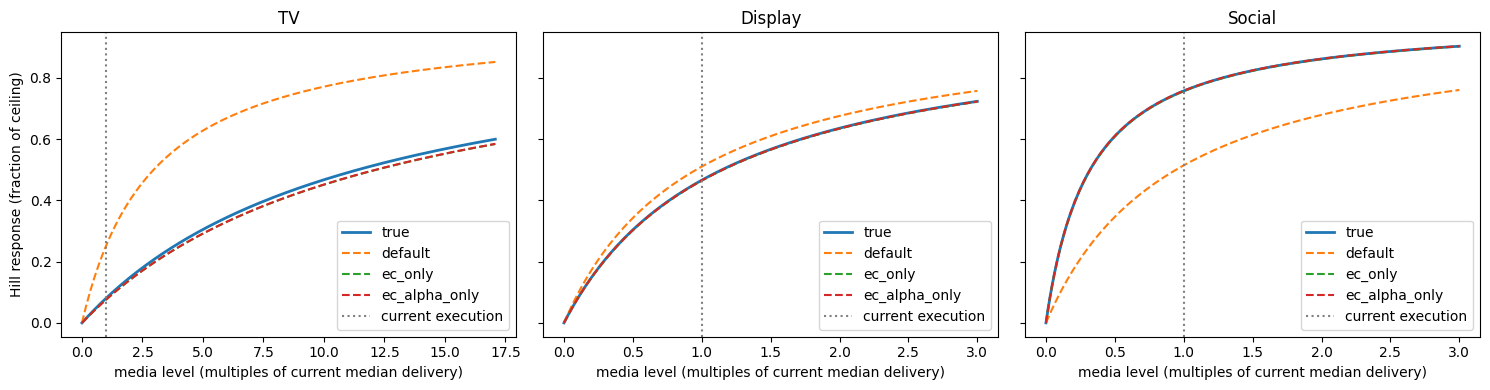

In [6]:
true_slope_m = sim.slope_m.numpy()

fig, axes = plt.subplots(1, len(config.channel_names), figsize=(15, 4), sharey=True)
for i, ch in enumerate(config.channel_names):
  x_max = max(3.0, true_ec_m[i] * 1.5)
  x_grid = np.linspace(0, x_max, 200)

  ax = axes[i]
  ax.plot(
      x_grid,
      hill_value(x_grid, true_ec_m[i], true_slope_m[i])[:, 0],
      label='true',
      linewidth=2,
  )
  for variant in MAIN_VARIANTS:
    posterior_ec = posterior_param_mean(fitted_mmms[variant], 'ec_m')[i]
    posterior_slope = posterior_param_mean(fitted_mmms[variant], 'slope_m')[i]
    ax.plot(
        x_grid,
        hill_value(x_grid, posterior_ec, posterior_slope)[:, 0],
        label=variant,
        linestyle='--',
    )
  ax.axvline(1.0, color='gray', linestyle=':', label='current execution')
  ax.set_title(ch)
  ax.set_xlabel('media level (multiples of current median delivery)')
  if i == 0:
    ax.set_ylabel('Hill response (fraction of ceiling)')
  ax.legend()
plt.tight_layout()
plt.show()

## 4. Marginal response at current execution

A unit-free finite-difference derivative of the Hill curve at `x=1`: how
much incremental (fraction-of-ceiling) response the next bit of delivery
buys, under truth vs. each fitted model.

In [7]:
def marginal_response(ec, slope, x=1.0, h=1e-3):
  return (hill_value(x + h, ec, slope) - hill_value(x - h, ec, slope)) / (2 * h)


marginal_rows = []
for i, ch in enumerate(config.channel_names):
  row = {'channel': ch, 'true': marginal_response(true_ec_m[i], true_slope_m[i])[0]}
  for variant in MAIN_VARIANTS:
    posterior_ec = posterior_param_mean(fitted_mmms[variant], 'ec_m')[i]
    posterior_slope = posterior_param_mean(fitted_mmms[variant], 'slope_m')[i]
    row[variant] = marginal_response(posterior_ec, posterior_slope)[0]
  marginal_rows.append(row)

pd.DataFrame(marginal_rows).set_index('channel')

,true,default,ec_only,ec_alpha_only
channel,,,,
TV,0.074204,0.188798,0.070244,0.070374
Display,0.248879,0.249863,0.248745,0.248820
Social,0.183582,0.249803,0.184000,0.183344


## 5. Budget-reallocation comparison

Does the misdiagnosis in Sections 2-4 actually change a budget decision?
Compute the true-DGP-optimal allocation directly from the simulator's own
known generative parameters (rescale impressions by a per-channel
multiplier, holding CPM fixed, re-apply the true adstock/Hill transform and
`beta_gm`, and numerically maximize incremental revenue under a fixed
total-budget constraint), then compare each fitted model's `BudgetOptimizer`
recommendation against it.

A review of the companion notebook found that `BudgetOptimizer.optimize()`'s
default fixed-budget spend-change bound (`+/-30%` of each channel's current
spend) clipped every variant to an identical recommendation before the
underlying model disagreement ever mattered -- both `default` and the
informed variant hit the same wall. This section reports both: the
default-bound comparison (to show the clipping explicitly) and a
deliberately widened bound (to let the actual model disagreement show up in
the dollar recommendation).

In [8]:
# Total incremental revenue by channel under a spend multiplier vector:
# rescales impressions, holding CPM fixed, and re-applies the true
# adstock/Hill transform and beta_gm (not the fitted model's estimates).
def true_incremental_revenue(multipliers_m):
  scaled_impressions_gtm = sim.impression_gtm.numpy() * np.asarray(
      multipliers_m, dtype=np.float32
  )[np.newaxis, np.newaxis, :]
  scaled_transformed_ipc_gtm = sim.impression_transformer.forward(
      scaled_impressions_gtm
  ).numpy()
  adstock_transformer = adstock_hill.AdstockTransformer(
      alpha=sim.alpha_m, max_lag=8, n_times_output=config.n_times
  )
  hill_transformer = adstock_hill.HillTransformer(ec=sim.ec_m, slope=sim.slope_m)
  media_transformed = hill_transformer.forward(
      adstock_transformer.forward(scaled_transformed_ipc_gtm)
  ).numpy()
  return np.einsum(
      'g,gt,gtm,gm->m',
      sim.p_g.numpy(),
      sim.unit_value.numpy(),
      media_transformed,
      sim.beta_gm.numpy(),
  )


def neg_total_revenue(multipliers_m):
  return -true_incremental_revenue(multipliers_m).sum()


# `sim`'s tensors are float32, so SciPy's default numerical-gradient step
# (~1e-8, tuned for float64) underflows float32 precision; a larger, explicit
# central-difference step avoids that.
def neg_total_revenue_grad(multipliers_m, h=1e-3):
  grad = np.zeros(config.n_imp_channels)
  for i in range(config.n_imp_channels):
    m_up, m_down = np.array(multipliers_m, dtype=np.float64), np.array(
        multipliers_m, dtype=np.float64
    )
    m_up[i] += h
    m_down[i] -= h
    grad[i] = -(
        true_incremental_revenue(m_up).sum() - true_incremental_revenue(m_down).sum()
    ) / (2 * h)
  return grad


current_cost_m = sim.cost_gtm.numpy().sum(axis=(0, 1))
total_budget = current_cost_m.sum()

budget_constraint = {
    'type': 'eq',
    'fun': lambda m: np.sum(current_cost_m * m) - total_budget,
    'jac': lambda m: current_cost_m,
}
result = minimize(
    neg_total_revenue,
    x0=np.ones(config.n_imp_channels),
    jac=neg_total_revenue_grad,
    method='SLSQP',
    bounds=[(0.0, None)] * config.n_imp_channels,
    constraints=[budget_constraint],
    options={'maxiter': 200, 'ftol': 1e-10},
)
true_optimal_spend_m = current_cost_m * result.x
result.success, result.message

(True, 'Optimization terminated successfully')

In [9]:
reallocation_df = pd.DataFrame({'channel': config.channel_names})
reallocation_df['current_spend'] = current_cost_m
reallocation_df['true_optimal_spend'] = true_optimal_spend_m

for variant in MAIN_VARIANTS:
  budget_optimizer = optimizer.BudgetOptimizer(meridian=fitted_mmms[variant])
  optimization_results = budget_optimizer.optimize()  # default +/-30% bound
  reallocation_df[f'{variant}_default_bound'] = (
      optimization_results.optimized_data['spend']
      .sel(channel=config.channel_names)
      .values
  )

# Widen the bound so the true optimal (which can be several multiples of
# current spend for the most under-invested channel) is actually reachable,
# letting the two models' recommendations genuinely diverge instead of both
# hitting the same default +/-30% wall.
WIDE_BOUND_LOWER = 1.0  # max allowed: can reduce spend all the way to 0.
WIDE_BOUND_UPPER = 2.0  # +200%, i.e. spend can go up to 3x current.

for variant in MAIN_VARIANTS:
  budget_optimizer = optimizer.BudgetOptimizer(meridian=fitted_mmms[variant])
  optimization_results = budget_optimizer.optimize(
      spend_constraint_lower=WIDE_BOUND_LOWER,
      spend_constraint_upper=WIDE_BOUND_UPPER,
      # Coarser grid (default gtol=0.0001) -- a wider spend range at the
      # same relative precision means far more grid points to evaluate;
      # gtol=0.005 keeps this fast while still accurate to ~0.5% of budget.
      gtol=0.005,
  )
  reallocation_df[f'{variant}_wide_bound'] = (
      optimization_results.optimized_data['spend']
      .sel(channel=config.channel_names)
      .values
  )

reallocation_df.set_index('channel')

,current_spend,true_optimal_spend,default_default_bound,ec_only_default_bound,ec_alpha_only_default_bound,default_wide_bound,ec_only_wide_bound,ec_alpha_only_wide_bound
channel,,,,,,,,
TV,57000408.0,2.623765e+08,74100000.0,74100000.0,74100000.0,180000000.0,180000000.0,180000000.0
Display,19425014.0,1.035453e+07,25100000.0,25200000.0,25200000.0,20000000.0,20000000.0,40000000.0
Social,251040784.0,5.473513e+07,228200000.0,228100000.0,228100000.0,130000000.0,130000000.0,110000000.0


## Conclusion

_TODO: fill in after review of the executed results._